# Lab 2B – Word2Vec Word Embeddings

## Aim
Train a **Word2Vec** model using a suitable text corpus to generate distributed word representations, perform **word vector arithmetic** to explore semantic relationships, and visualize word embeddings using **t-SNE** to interpret contextual similarities among words.

## Objective

This lab demonstrates how words can be represented as numerical vectors and how these vectors can capture relationships between words.

### Pipeline
**Text Corpus → Preprocess Text → Train Word2Vec → Explore Word Vectors → Vector Arithmetic → t-SNE Visualization**

In [1]:
!pip install gensim matplotlib


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [4]:
!pip install scikit-learn

  Using cached narwhals-2.25.0-py3-none-any.whl.metadata (15 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 4.3 MB/s eta 0:00:00a 0:00:01
Using cached narwhals-2.25.0-py3-none-any.whl (467 kB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)

[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [5]:
# Install/import the required libraries
# If gensim is not installed, run in Terminal:
# python -m pip install gensim scikit-learn matplotlib pandas

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from gensim.models import Word2Vec
from sklearn.manifold import TSNE

print("Libraries imported successfully.")

Libraries imported successfully.


## 1. Prepare a Text Corpus

We use a small corpus containing sentences about people, places, technology, education, and activities.

A slightly larger corpus is used so that Word2Vec has enough repeated context to learn meaningful relationships.

In [6]:
corpus = [
    "king queen prince princess royal family palace",
    "king rules the kingdom and queen rules the palace",
    "prince and princess live in the royal palace",
    "man woman boy girl person family",
    "men and women work together in the organization",
    "boys and girls learn together at school",
    "teacher student school education learning",
    "teachers help students learn new concepts",
    "students study computer science and artificial intelligence",
    "computer science includes programming algorithms and data",
    "python programming is useful for artificial intelligence",
    "machine learning and deep learning are areas of artificial intelligence",
    "deep learning uses neural networks to learn patterns",
    "technology companies develop software and artificial intelligence",
    "software engineers write programs using python and other languages",
    "india has cities such as chennai bengaluru and mumbai",
    "chennai is a city in india",
    "bengaluru is a technology city in india",
    "mumbai is a large city in india",
    "paris is a city in france",
    "france is a country in europe",
    "india and france have cities and universities",
    "students visit universities to learn and study",
    "teachers and students work together on projects",
    "researchers develop new technology using machine learning"
]

print("Number of sentences:", len(corpus))

Number of sentences: 25


## 2. Preprocess the Corpus

Word2Vec works with a sequence of words. We convert the sentences to lowercase and remove punctuation.

In [7]:
def preprocess(sentence):
    sentence = sentence.lower()
    sentence = re.sub(r"[^a-z\s]", "", sentence)
    return sentence.split()

tokenized_corpus = [preprocess(sentence) for sentence in corpus]

print("Original sentence:")
print(corpus[0])

print("\nTokenized sentence:")
print(tokenized_corpus[0])

Original sentence:
king queen prince princess royal family palace

Tokenized sentence:
['king', 'queen', 'prince', 'princess', 'royal', 'family', 'palace']


## 3. Train the Word2Vec Model

Word2Vec learns a vector representation for each word based on the words that appear around it.

- `vector_size=50` → each word gets a 50-dimensional vector.
- `window=3` → nearby words within a window of 3 are considered.
- `min_count=1` → keep all words in this small teaching corpus.
- `sg=1` → use the Skip-gram training method.

In [8]:
model = Word2Vec(
    sentences=tokenized_corpus,
    vector_size=50,
    window=3,
    min_count=1,
    workers=1,
    sg=1,
    epochs=200,
    seed=42
)

print("Word2Vec model trained successfully.")
print("Vocabulary size:", len(model.wv))

Word2Vec model trained successfully.
Vocabulary size: 91


## 4. Inspect a Word Vector

Each word is represented by a numerical vector.

In [9]:
word = "king"

print(f"Vector for '{word}':")
print(model.wv[word])

print("\nVector dimensions:", len(model.wv[word]))

Vector for 'king':
[ 0.03137549 -0.1316248  -0.08785323 -0.09379014  0.04166127  0.1108437
 -0.00478594  0.16091397 -0.27017924 -0.00485722 -0.1817967   0.2951099
 -0.18307167  0.41184855  0.10421314 -0.03745939  0.00672599 -0.23970568
  0.02062048 -0.09965946  0.03028517  0.06026145  0.08047958  0.08292677
  0.38040718  0.03009467  0.06207836  0.0433508  -0.15955742  0.04432552
  0.05354993 -0.11207319 -0.10463064  0.128494   -0.00242252 -0.16669102
  0.03826926 -0.48750764 -0.03573011  0.1395942  -0.11091256  0.10448492
  0.39414364 -0.2650393   0.02853862  0.07439862 -0.04554377  0.4229378
  0.19698727 -0.19554645]

Vector dimensions: 50


## 5. Find Similar Words

Word2Vec can find words whose vectors are close to a selected word.

The results depend on the training corpus and model settings.

In [10]:
def show_similar(word, topn=5):
    if word in model.wv:
        return pd.DataFrame(
            model.wv.most_similar(word, topn=topn),
            columns=["Word", "Similarity"]
        )
    else:
        print(f"'{word}' is not in the vocabulary.")

show_similar("king")

,Word,Similarity
0,palace,0.996149
1,the,0.995840
2,queen,0.995534
3,prince,0.995305
4,princess,0.994859


## 6. Word Vector Arithmetic

Word vectors can be combined to explore semantic relationships.

We use the classic idea:

**king − man + woman ≈ queen**

Because this is a small teaching corpus, the exact result may differ from the ideal relationship.

In [11]:
result = model.wv.most_similar(
    positive=["king", "woman"],
    negative=["man"],
    topn=5
)

pd.DataFrame(result, columns=["Word", "Similarity"])

,Word,Similarity
0,the,0.993501
1,prince,0.992545
2,palace,0.992021
3,princess,0.991979
4,royal,0.990941


### Another Example

Explore a country/city relationship using the learned vectors.

In [12]:
result = model.wv.most_similar(
    positive=["india", "paris"],
    negative=["france"],
    topn=5
)

pd.DataFrame(result, columns=["Word", "Similarity"])

,Word,Similarity
0,education,0.984142
1,school,0.982300
2,city,0.981631
3,men,0.981354
4,student,0.980957


## 7. Compare Selected Word Relationships

We can directly measure the similarity between two words using cosine similarity.

In [13]:
pairs = [
    ("king", "queen"),
    ("teacher", "student"),
    ("computer", "programming"),
    ("machine", "learning"),
    ("india", "chennai"),
    ("india", "bengaluru")
]

similarity_results = []

for word1, word2 in pairs:
    similarity_results.append({
        "Word 1": word1,
        "Word 2": word2,
        "Cosine Similarity": model.wv.similarity(word1, word2)
    })

pd.DataFrame(similarity_results)

,Word 1,Word 2,Cosine Similarity
0,king,queen,0.995533
1,teacher,student,0.995356
2,computer,programming,0.994360
3,machine,learning,0.995566
4,india,chennai,0.995836
5,india,bengaluru,0.993678


## 8. Prepare Word Vectors for t-SNE

t-SNE reduces high-dimensional vectors to **2 dimensions** so that we can visualize relationships between words.

In [14]:
selected_words = [
    "king", "queen", "prince", "princess",
    "man", "woman", "boy", "girl",
    "teacher", "student", "school", "education",
    "computer", "programming", "python",
    "machine", "learning", "deep", "technology",
    "india", "chennai", "bengaluru", "mumbai",
    "paris", "france"
]

selected_words = [word for word in selected_words if word in model.wv]
vectors = np.array([model.wv[word] for word in selected_words])

print("Words selected for visualization:", len(selected_words))
print("Original vector shape:", vectors.shape)

Words selected for visualization: 25
Original vector shape: (25, 50)


## 9. t-SNE Visualization

t-SNE maps similar high-dimensional word vectors closer together in a 2D space.

**Note:** The exact positions can change because t-SNE is a dimensionality-reduction technique and this is a small training corpus.

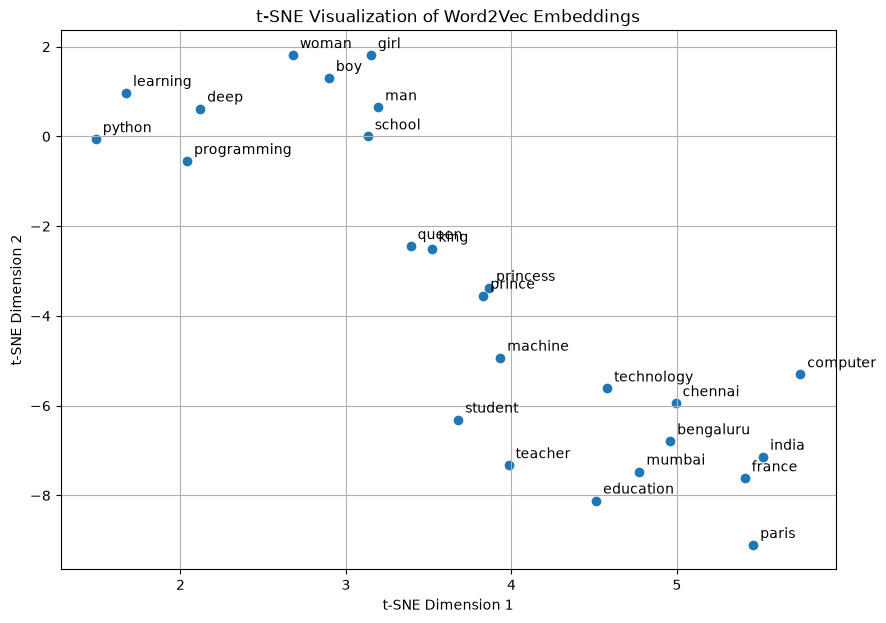

In [15]:
perplexity = min(10, len(selected_words) - 1)

tsne = TSNE(
    n_components=2,
    perplexity=perplexity,
    random_state=42,
    init="random",
    learning_rate="auto"
)

vectors_2d = tsne.fit_transform(vectors)

plt.figure(figsize=(10, 7))

plt.scatter(vectors_2d[:, 0], vectors_2d[:, 1])

for i, word in enumerate(selected_words):
    plt.annotate(
        word,
        (vectors_2d[i, 0], vectors_2d[i, 1]),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.title("t-SNE Visualization of Word2Vec Embeddings")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.grid(True)
plt.show()

## 10. Interpretation

From the Word2Vec model:

- Words appearing in similar contexts tend to have similar vector representations.
- Similarity scores help identify words with related contexts.
- Vector arithmetic demonstrates that relationships can be represented mathematically.
- t-SNE provides a 2D visual representation of the learned word embeddings.
- Words that appear close together in the visualization may have similar contextual representations.

Because this is a **small educational corpus**, the results are illustrative rather than a representation of general English language semantics.

## 11. Analysis Questions

1. What is a word embedding?
2. How does Word2Vec represent a word?
3. What is the role of the context window in Word2Vec?
4. What is the difference between a word and its vector representation?
5. What does cosine similarity tell us?
6. What is meant by word vector arithmetic?
7. Why can `king - man + woman` produce a word related to `queen`?
8. Why do we use t-SNE?
9. What does it mean when two words appear close together in a t-SNE plot?
10. Why might the results from a small corpus differ from a large pretrained Word2Vec model?

## Conclusion

A Word2Vec model was trained on a text corpus to generate distributed word representations. Word vectors were inspected, semantic relationships were explored using vector arithmetic and similarity measures, and t-SNE was used to visualize the embeddings in two dimensions. The experiment demonstrates how **context can be used to learn meaningful numerical representations of words**.